<a href="https://colab.research.google.com/github/gerget47/Struktury-i-algoritmy-obrabotki-dannykh/blob/main/%D0%BB%D0%B0%D0%B13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # 1 задание

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

class UnorderedList:
    def __init__(self):
        self.head = None

    def isEmpty(self):
        return self.head is None

    def add(self, item):
        temp = Node(item)
        temp.next = self.head
        self.head = temp

    def size(self):
        current = self.head
        count = 0
        while current:
            count += 1
            current = current.next
        return count

    def search(self, item):
        current = self.head
        while current:
            if current.data == item:
                return True
            current = current.next
        return False

    def remove(self, item):
        current = self.head
        previous = None
        while current:
            if current.data == item:
                if previous:
                    previous.next = current.next
                else:
                    self.head = current.next
                return
            previous = current
            current = current.next

    # 1. append(item) добавить в конец
    def append(self, item):
        temp = Node(item)
        if self.isEmpty():
            self.head = temp
        else:
            current = self.head
            while current.next:
                current = current.next
            current.next = temp

    # index(item) вернуть позицию элемента
    def index(self, item):
        current = self.head
        pos = 0
        while current:
            if current.data == item:
                return pos
            pos += 1
            current = current.next
        raise ValueError(f"{item} не найден в списке")

    # insert(pos, item) вставить на позицию
    def insert(self, pos, item):
        if pos == 0:
            self.add(item)
            return
        temp = Node(item)
        current = self.head
        for _ in range(pos - 1):
            if current is None:
                raise IndexError("позиция выходит за границы списка")
            current = current.next
        temp.next = current.next
        current.next = temp

    # pop() удалить последний
    def pop(self):
        if self.isEmpty():
            raise IndexError("удаление из пустого списка")
        if self.head.next is None:
            data = self.head.data
            self.head = None
            return data
        current = self.head
        while current.next.next:
            current = current.next
        data = current.next.data
        current.next = None
        return data

    # pop(pos) удалить с позиции
    def pop_pos(self, pos):
        if self.isEmpty():
            raise IndexError("удаление из пустого списка")
        if pos == 0:
            data = self.head.data
            self.head = self.head.next
            return data
        current = self.head
        for _ in range(pos - 1):
            if current is None or current.next is None:
                raise IndexError("позиция выходит за границы списка")
            current = current.next
        data = current.next.data
        current.next = current.next.next
        return data

    # 2. __str__ отображение в стиле Python
    def __str__(self):
        result = []
        current = self.head
        while current:
            result.append(repr(current.data))
            current = current.next
        return "[" + ", ".join(result) + "]"

    # 3. срез [start:stop]
    def slice(self, start, stop):
        if start < 0 or stop < 0:
            raise ValueError("start и stop должны быть неотрицательными")
        if start >= stop:
            return UnorderedList()
        current = self.head
        for _ in range(start):
            if current is None:
                return UnorderedList()
            current = current.next
        new_list = UnorderedList()
        items = []
        for _ in range(stop - start):
            if current is None:
                break
            items.append(current.data)
            current = current.next
        for item in reversed(items):
            new_list.add(item)
        return new_list


if __name__ == "__main__":
    lst = UnorderedList()
    lst.append(1)
    lst.append(2)
    lst.append(3)
    lst.insert(1, 99)
    print(lst)
    print(lst.index(99))
    print(lst.pop())
    print(lst.pop_pos(1))
    print(lst)
    print(lst.slice(0, 2))

[1, 99, 2, 3]
1
3
99
[1, 2]
[1, 2]


In [ ]:
# 2 задание

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

class UnorderedList:
    def __init__(self):
        self.head = None

    def isEmpty(self):
        return self.head is None

    def add(self, item):
        temp = Node(item)
        temp.next = self.head
        self.head = temp

    def remove(self, item):
        current = self.head
        previous = None
        while current:
            if current.data == item:
                if previous:
                    previous.next = current.next
                else:
                    self.head = current.next
                return True
            previous = current
            current = current.next
        return False

    def search(self, item):
        current = self.head
        while current:
            if current.data == item:
                return True
            current = current.next
        return False

    def __str__(self):
        result = []
        current = self.head
        while current:
            result.append(str(current.data))
            current = current.next
        return "[" + ", ".join(result) + "]"


def move_to_front():
    lst = UnorderedList()
    n = int(input("введите количество строк "))
    for _ in range(n):
        s = input("введите строку ")
        if lst.search(s):
            lst.remove(s)
        lst.add(s)
        print(f"список после ввода '{s}': {lst}")
    return lst


# Тестирование
if __name__ == "__main__":
    result = move_to_front()
    print(f"итоговый список {result}")


введите количество строк 3
введите строку 6
список после ввода '6': [6]
введите строку 7
список после ввода '7': [7, 6]
введите строку 6
список после ввода '6': [6, 7]
итоговый список [6, 7]


In [ ]:
# 3 задание (итеративный вариант)

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

def reverse_iterative(head):
    prev = None
    current = head
    while current:
        next_node = current.next
        current.next = prev
        prev = current
        current = next_node
    return prev

head = Node(1)
head.next = Node(2)
head.next.next = Node(3)

def print_list(head):
    while head:
        print(head.data, end=" ")
        head = head.next
    print()

print("исходный", end=" ")
print_list(head)
head = reverse_iterative(head)
print("развёрнутый", end=" ")
print_list(head)

исходный 1 2 3 
развёрнутый 3 2 1 


In [ ]:
# 3 задание (рекурсивный вариант)

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

def reverse_recursive(head):
    if head is None or head.next is None:
        return head
    new_head = reverse_recursive(head.next)
    head.next.next = head
    head.next = None
    return new_head

head = Node(1)
head.next = Node(2)
head.next.next = Node(3)

def print_list(head):
    while head:
        print(head.data, end=" ")
        head = head.next
    print()

print("исходный", end=" ")
print_list(head)
head = reverse_recursive(head)
print("развёрнутый", end=" ")
print_list(head)

исходный 1 2 3 
развёрнутый 3 2 1 


In [1]:
# 4 задание

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

class UnorderedList:
    def __init__(self):
        self.head = None

    def isEmpty(self):
        return self.head is None

    def add(self, item):
        temp = Node(item)
        temp.next = self.head
        self.head = temp

    def append(self, item):
        temp = Node(item)
        if self.isEmpty():
            self.head = temp
        else:
            current = self.head
            while current.next:
                current = current.next
            current.next = temp

    def pop(self):
        if self.isEmpty():
            raise IndexError
        if self.head.next is None:
            data = self.head.data
            self.head = None
            return data
        current = self.head
        while current.next.next:
            current = current.next
        data = current.next.data
        current.next = None
        return data

    def pop_first(self):
        if self.isEmpty():
            raise IndexError
        data = self.head.data
        self.head = self.head.next
        return data

    def size(self):
        count = 0
        current = self.head
        while current:
            count += 1
            current = current.next
        return count


# Стек
class Stack:
    def __init__(self):
        self._list = UnorderedList()

    def push(self, item):
        self._list.add(item)

    def pop(self):
        return self._list.pop_first()

    def peek(self):
        if self.isEmpty():
            raise IndexError
        return self._list.head.data

    def isEmpty(self):
        return self._list.isEmpty()

    def size(self):
        return self._list.size()


# Очередь
class Queue:
    def __init__(self):
        self._list = UnorderedList()

    def enqueue(self, item):
        self._list.append(item)

    def dequeue(self):
        return self._list.pop_first()

    def isEmpty(self):
        return self._list.isEmpty()

    def size(self):
        return self._list.size()


# Дек
class Deque:
    def __init__(self):
        self._list = UnorderedList()

    def addFront(self, item):
        self._list.add(item)

    def addRear(self, item):
        self._list.append(item)

    def removeFront(self):
        return self._list.pop_first()

    def removeRear(self):
        return self._list.pop()

    def isEmpty(self):
        return self._list.isEmpty()

    def size(self):
        return self._list.size()


if __name__ == "__main__":
    print("       Стек")
    s = Stack()
    s.push(1)
    s.push(2)
    s.push(3)
    print(s.pop())
    print(s.pop())
    print(s.isEmpty())
    print(s.pop())
    print(s.isEmpty())

    print("\n     Очередь ")
    q = Queue()
    q.enqueue(1)
    q.enqueue(2)
    q.enqueue(3)
    print(q.dequeue())
    print(q.dequeue())
    print(q.dequeue())

    print("\n       Дек")
    d = Deque()
    d.addFront(1)
    d.addRear(2)
    d.addFront(3)
    print(d.removeFront())
    print(d.removeRear())
    print(d.removeFront())

       Стек
3
2
False
1
True

     Очередь 
1
2
3

       Дек
3
2
1


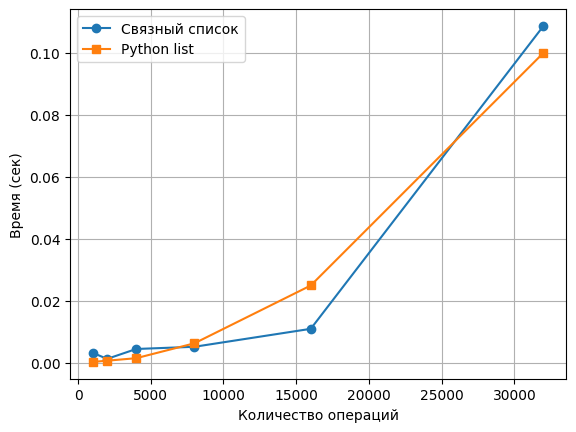

In [ ]:
# 4 задание (сравнение производительности)

import time
import matplotlib.pyplot as plt

class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

class LinkedQueue:
    def __init__(self):
        self.head = None
        self.tail = None
        self._size = 0

    def enqueue(self, item):
        node = Node(item)
        if self.tail:
            self.tail.next = node
        else:
            self.head = node
        self.tail = node
        self._size += 1

    def dequeue(self):
        if not self.head:
            raise IndexError("empty")
        data = self.head.data
        self.head = self.head.next
        if not self.head:
            self.tail = None
        self._size -= 1
        return data

    def size(self):
        return self._size


sizes = [1000, 2000, 4000, 8000, 16000, 32000]
times_linked = []
times_python = []

for size in sizes:

    # связный список
    ql = LinkedQueue()
    start = time.perf_counter()
    for i in range(size):
        ql.enqueue(i)
    for _ in range(size):
        ql.dequeue()
    times_linked.append(time.perf_counter() - start)

    # Python list
    qp = []
    start = time.perf_counter()
    for i in range(size):
        qp.append(i)
    for _ in range(size):
        qp.pop(0)
    times_python.append(time.perf_counter() - start)

plt.plot(sizes, times_linked, 'o-', label='Связный список')
plt.plot(sizes, times_python, 's-', label='Python list')
plt.xlabel('Количество операций')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 5 задание

class DoubleNode:
    def __init__(self, data):
        self.data = data
        self.next = None
        self.prev = None

class DoubleList:
    def __init__(self):
        self.head = None
        self.tail = None
        self._size = 0

    def isEmpty(self):

    #Проверка на пустоту
        return self.head is None

    def size(self):

    #Количество элементов
        return self._size

    def search(self, item):

    #Поиск элемента (True/False)
        current = self.head
        while current:
            if current.data == item:
                return True
            current = current.next
        return False

    def addFront(self, item):

    #Вставка в начало
        node = DoubleNode(item)
        if self.isEmpty():
            self.tail = node
        else:
            node.next = self.head
            self.head.prev = node
        self.head = node
        self._size += 1

    def addRear(self, item):

     #Вставка в конец
        node = DoubleNode(item)
        if self.isEmpty():
            self.head = node
        else:
            node.prev = self.tail
            self.tail.next = node
        self.tail = node
        self._size += 1

    def removeFront(self):

      #Удаление из начала
        if self.isEmpty():
            raise IndexError("empty")
        data = self.head.data
        self.head = self.head.next
        if self.head:
            self.head.prev = None
        else:
            self.tail = None
        self._size -= 1
        return data

    def removeRear(self):

      #Удаление из конца
        if self.isEmpty():
            raise IndexError("empty")
        data = self.tail.data
        self.tail = self.tail.prev
        if self.tail:
            self.tail.next = None
        else:
            self.head = None
        self._size -= 1
        return data

    def insertBefore(self, target, item):

    #Вставка перед указанным узлом
        current = self.head
        while current:
            if current.data == target:
                node = DoubleNode(item)
                node.prev = current.prev
                node.next = current
                if current.prev:
                    current.prev.next = node
                else:
                    self.head = node
                current.prev = node
                self._size += 1
                return
            current = current.next
        raise ValueError(f"{target} not found")

    def insertAfter(self, target, item):

    #Вставка после указанного узла
        current = self.head
        while current:
            if current.data == target:
                node = DoubleNode(item)
                node.next = current.next
                node.prev = current
                if current.next:
                    current.next.prev = node
                else:
                    self.tail = node
                current.next = node
                self._size += 1
                return
            current = current.next
        raise ValueError(f"{target} not found")

    def removeNode(self, target):

    #Удаление указанного узла
        current = self.head
        while current:
            if current.data == target:
                if current.prev:
                    current.prev.next = current.next
                else:
                    self.head = current.next
                if current.next:
                    current.next.prev = current.prev
                else:
                    self.tail = current.prev
                self._size -= 1
                return
            current = current.next
        raise ValueError(f"{target} not found")

    def __str__(self):
        result = []
        current = self.head
        while current:
            result.append(str(current.data))
            current = current.next
        return "[" + ", ".join(result) + "]"


if __name__ == "__main__":
    dl = DoubleList()
    dl.addFront(1)
    dl.addRear(3)
    dl.insertAfter(1, 2)
    dl.insertBefore(3, 2.5)
    print(dl)

    print(dl.size())
    print(dl.search(2))

    dl.removeNode(2.5)
    print(dl)

    print(dl.removeFront())
    print(dl.removeRear())
    print(dl)

    print(dl.isEmpty())
    dl.removeFront()
    print(dl.isEmpty())

[1, 2, 2.5, 3]
4
True
[1, 2, 3]
1
3
[2]
False
True


In [ ]:
# 6 задание

class Stack:
    def __init__(self):
        self.items = []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        if self.isEmpty():
            return None
        return self.items.pop()

    def isEmpty(self):
        return len(self.items) == 0


def check_html(html):
    stack = Stack()
    i = 0
    while i < len(html):
        if html[i] == '<' and html[i+1] != '/':

            # открывающий тег
            j = html.find('>', i)
            tag = html[i+1:j]
            stack.push(tag)
            i = j
        elif html[i] == '<' and html[i+1] == '/':

            # закрывающий тег
            j = html.find('>', i)
            tag = html[i+2:j]
            if stack.isEmpty() or stack.pop() != tag:
                return False
            i = j
        i += 1
    return stack.isEmpty()


html1 = "<html><head><title>Example</title></head><body>Hello</body></html>"
html2 = "<html><head><title>Example</head></html>"

print(check_html(html1))
print(check_html(html2))

True
False


In [ ]:
# 7 задание

class Stack:
    def __init__(self):
        self.items = []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        if self.isEmpty():
            return None
        return self.items.pop()

    def isEmpty(self):
        return len(self.items) == 0


def calc(expression):
    stack = Stack()
    tokens = expression.split()

    for token in tokens:
        if token.isdigit() or (token[0] == '-' and token[1:].isdigit()):
            stack.push(int(token))
        elif token in '+-*/':
            b = stack.pop()
            a = stack.pop()
            if a is None or b is None:
                return "Ошибка: недостаточно операндов"
            if token == '+':
                stack.push(a + b)
            elif token == '-':
                stack.push(a - b)
            elif token == '*':
                stack.push(a * b)
            elif token == '/':
                if b == 0:
                    return "Ошибка: деление на ноль"
                stack.push(a / b)
        else:
            return f"Ошибка: неизвестный токен '{token}'"

    result = stack.pop()
    if not stack.isEmpty():
        return "Ошибка: в стеке остались лишние операнды"
    return result


print(calc("3 4 +"))
print(calc("10 2 /"))
print(calc("6 7 + 0 /"))
print(calc("3 4 + 2 *"))
print(calc("3 4 + -"))
print(calc("3 а +"))
print(calc("3 4 5 + "))

7
5.0
Ошибка: деление на ноль
14
Ошибка: недостаточно операндов
Ошибка: неизвестный токен 'а'
Ошибка: в стеке остались лишние операнды


In [ ]:
# 8 задание

import random
import time

class Queue:
    def __init__(self):
        self.items = []

    def enqueue(self, item):
        self.items.append(item)

    def dequeue(self):
        if self.isEmpty():
            return None
        return self.items.pop(0)

    def isEmpty(self):
        return len(self.items) == 0

    def size(self):
        return len(self.items)

class Customer:
    def __init__(self, arrive_time, service_time):
        self.arrive_time = arrive_time
        self.service_time = service_time

def simulate(total_time, avg_arrive, avg_service):
    queue = Queue()
    wait_times = []

    next_arrive = random.expovariate(1 / avg_arrive)
    next_service = float('inf')
    current_customer = None

    for current_time in range(total_time):

        # новый покупатель
        if current_time >= next_arrive:
            service = random.expovariate(1 / avg_service)
            queue.enqueue(Customer(current_time, service))
            next_arrive += random.expovariate(1 / avg_arrive)

        # касса свободна и есть очередь
        if current_customer is None and not queue.isEmpty():
            current_customer = queue.dequeue()
            wait = current_time - current_customer.arrive_time
            wait_times.append(wait)
            next_service = current_time + current_customer.service_time

        # касса занята
        if current_customer and current_time >= next_service:
            current_customer = None

    if wait_times:
        avg_wait = sum(wait_times) / len(wait_times)
        return avg_wait, len(wait_times)
    return 0, 0

avg_wait, served = simulate(1000, 5, 4)
print(f"Среднее время ожидания: {avg_wait:.2f} сек")
print(f"Обслужено покупателей: {served}")

Среднее время ожидания: 37.94 сек
Обслужено покупателей: 178
